# Hernquist distribution
The aim of this notebook is to generate an unperturbed Hernquist distribution. We will then add two extra points which will simulate two black holes, to study the dynamical friction and their interaction.

The Henrquist profile is described by the follwing density distribution:

$$ \rho(r) = \frac{M}{2\pi}\frac{a}{r}\frac{1}{(r+a)^3} $$   
where $a$ is a scale radius. Note that for radii larger than $a$, the density goes as $r^{-4}$, at smaller radii it will instead go as r.

From the density distribution one can compute the mass distribution and the potential shape, assuming a spherical distribution. 

$$ M(R) = \int_0^R 4\pi r^2 \rho(r) dr  = \frac{M_{tot}R^2}{(R+a)^2}$$

$$ \phi_H (R) = -4\pi G\Bigl[\frac{1}{R} \int_0^R \rho(r) r^2 dr + \int_R^\infty \rho(r) r dr\Bigr] = - \frac{GM}{(R+a)}$$

In [2]:
#pip install scienceplots

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import scienceplots
plt.style.use(['science', 'no-latex'])

## Initialization

In [4]:
n = 30000 #number of particles
a = 2.0 #scale radius
M = 1.0 #each particle has a mass = M/n in internal units
n_dim = 3

In [5]:
def radius(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)
    
def v_circ(radius):
    return np.sqrt(M * radius) / (radius + a)

In [6]:
M_BH_1 = 0.01
M_BH_2 = 0.005

x_1, y_1, z_1 = 7.0, 0.0, 0.0
x_2, y_2, z_2 = -5.0, 0.0, 0.0
r_1 = radius(x_1, y_1, z_1)
r_2 = radius(x_2, y_2, z_2)

v_x1, v_y1, v_z1 = 0.0, v_circ(r_1), 0.0
v_x2, v_y2, v_z2 = 0.0, - v_circ(r_2), 0.0

## Position sampling
In order to create the profile, we need to sample the position and velociy of each of our n particles. To do this, we first find the radial distribution:

$$ P(R) = \frac{M(R)}{M_{tot}} = \frac{R^2}{(R + a)^2} $$

where $0 < P(R) < 1$. In this way we can sample from a uniform distribution and then convert that value into a radius:

$$ R = \frac{a\sqrt{P(R)}}{1-\sqrt{P(R)}}$$

Assuming spherical symmetry, the angular positions can instead be generated from:


$$ \Theta = \arccos{(1-2P(\Theta))}$$

$$ \Phi = {2\pi}P(\Phi)$$

where P once again is drawn from a uniform distribution.

In [7]:
def radius_from_P (P):
    return (a * np.sqrt(P)) / (1 - np.sqrt(P))

In [8]:
#samples ---------------------------------
P_R = np.random.uniform(0, 1, n)
radius = radius_from_P (P_R)
radius_s = np.sort(radius)

P_theta = np.random.uniform(0, 1, n)
theta = np.arccos(1 - 2*P_theta)

P_phi = np.random.uniform(0, 1, n)
phi = 2 * np.pi * P_phi

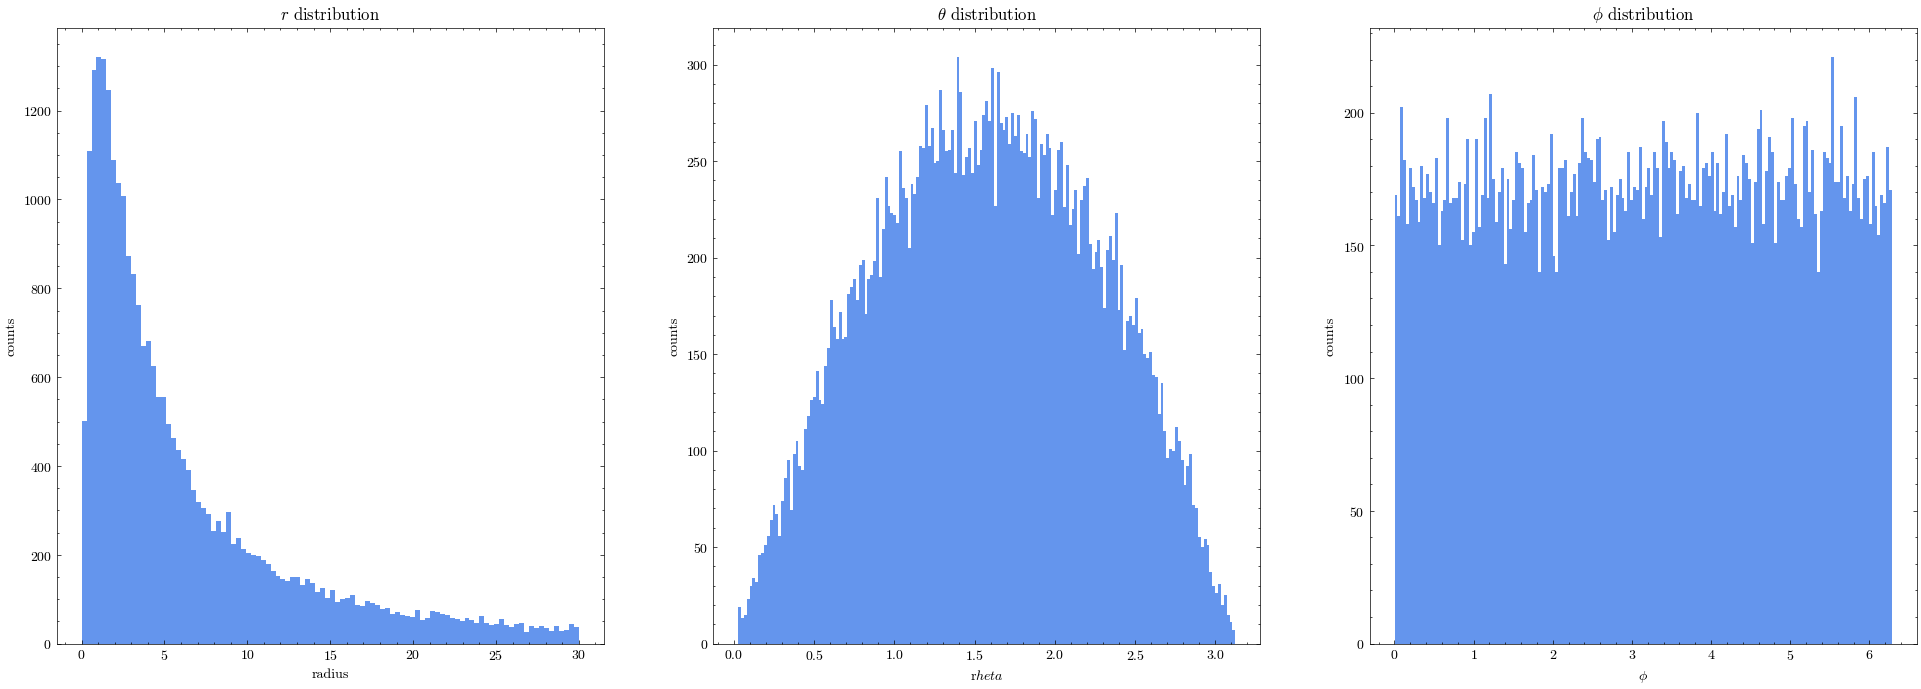

In [9]:
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,8))
ax[0].hist(radius_s, range=(0,30), bins = 100, color = 'cornflowerblue')
ax[0].set(title = '$r$ distribution', ylabel = "counts", xlabel = "radius")

ax[1].hist(theta, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[1].set(title = r'$\theta$ distribution', ylabel = "counts", xlabel = 'r$\theta$')
ax[1].plot()

ax[2].hist(phi, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[2].set(title = '$\phi$ distribution', ylabel = "counts", xlabel = "$\phi$")
ax[2].plot()

plt.show()

In [10]:
#carthesian coord conversion -----------
def sph_to_carth (radius, theta, phi):
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return x, y, z

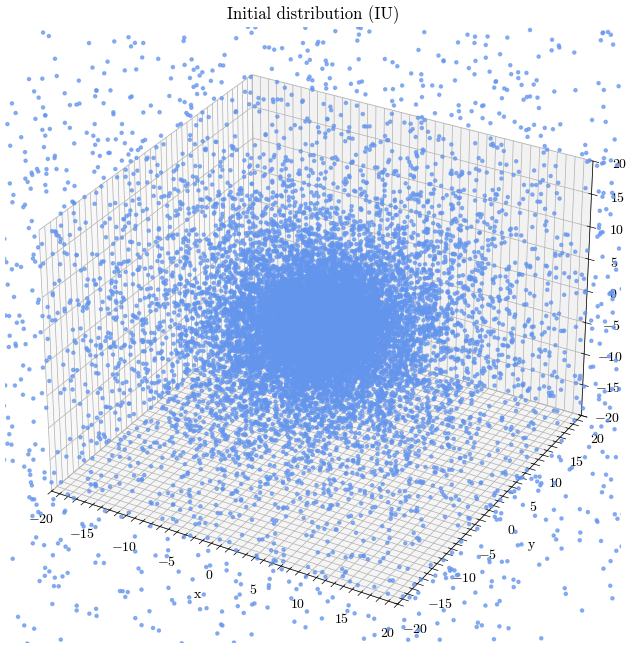

In [11]:
x, y, z = sph_to_carth(radius_s, theta, phi)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(x,y,z,s=5,alpha=0.7, color = 'cornflowerblue')
ax.scatter(x_1, y_1, z_1, color = 'r')
ax.scatter(x_2, y_2, z_2, color = 'g')
ax.set (title = 'Initial distribution (IU)', xlabel = 'x', ylabel = 'y', zlabel = 'z', xlim = (-20,20), ylim = (-20, 20), zlim = (-20, 20))

plt.show()

## Density check

In [12]:
def compute_rho(radius):
    return M/(2*np.pi) * a/radius * 1/(radius+a)**3

In [13]:
def count_particles(radius, r_min, r_max):
    return int(np.sum((radius > r_min) & (radius < r_max)))

def numerical_density(radius, n_check):
    grid = np.geomspace(min(radius), max(radius), n_check)
    rho = []
    grid_centres = []
    
    for i in range(n_check-1):
        dn = count_particles(radius, grid[i], grid[i+1]) 
        if dn > 1:
            grid_centres.append(float(grid[i+1]))
            dV = 4*np.pi/3 * (grid[i+1]**3 - grid_centres[len(grid_centres)-2]**3)
            rho.append( (M/n) * (dn/dV) )
    
    return rho, grid_centres

In [14]:
num_rho, rho_grid = numerical_density(radius_s, 500)

analytical_rho = [compute_rho(rg) for rg in rho_grid]

/tmp/ipykernel_1853/2502167543.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  rho.append( (M/n) * (dn/dV) )


[]

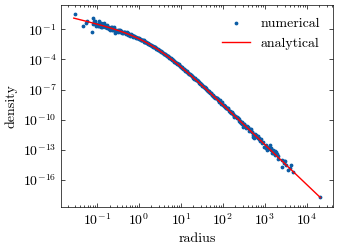

In [15]:
plt.scatter(rho_grid, num_rho, s = 3, label ='numerical')
plt.plot(rho_grid, analytical_rho , c = 'r', label = 'analytical')
plt.xlabel('radius')
plt.ylabel('density')
plt.legend()
plt.loglog()

## Velocity sampling

In [16]:
def compute_potential(radius):
    return - M / (radius + a)
    
def distribution_function(eps):
    v_g = np.sqrt(M/a)
    factor_1 = M/(8 * np.sqrt(2) * np.pi**3 * a**3 * v_g**3)
    factor_2 = 1 / (1-eps**2)**(5/2)
    term_1 = (3 * np.arcsin(eps))
    term_2 = eps * np.sqrt(1-eps**2) * (1-2*eps**2) * (8*eps**4 - 8*eps**2 - 3)

    return factor_1 * factor_2 * (term_1 + term_2)
    
def v_escape(radius):
    return np.sqrt(- 2 * compute_potential(radius))

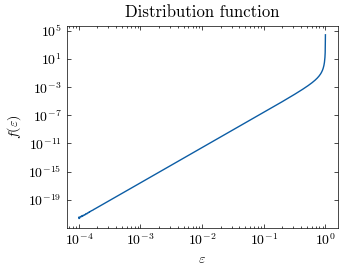

In [17]:
eps_values = np.geomspace(0.0001, 0.999, 1000)
f_values = distribution_function(eps_values)

norm = np.trapezoid(f_values, eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Distribution function')
plt.loglog()
plt.show()

In [18]:
print(f_values[f_values<0])

[]


In [19]:
print(norm)

122.89288054215112


In [20]:
def df_norm(eps):
    eps = np.sqrt(- eps / compute_potential(0) )
    return distribution_function(eps)/norm

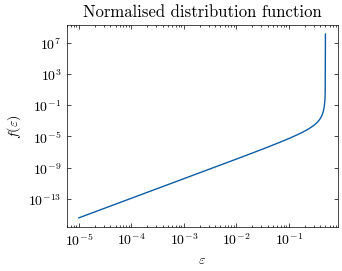

In [21]:
eps_values = np.geomspace(0.00001, - 0.99999 * compute_potential(0), 1000)
f_values = df_norm(eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Normalised distribution function')
plt.loglog()
plt.show()

In [22]:
from tqdm import tqdm

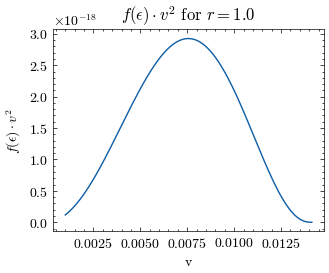

In [23]:
r=1E+4
phi_r = compute_potential(r)
v_max = v_escape(r)

v_vals = np.linspace(0.001, v_max, 500)
epsilon_vals = -(0.5 * v_vals**2 + phi_r)
f_v = df_norm(epsilon_vals) * v_vals**2

plt.plot(v_vals, f_v)
plt.xlabel("v")
plt.ylabel(r"$f(\epsilon) \cdot v^2$")
plt.title(r"$f(\epsilon) \cdot v^2$ for $r=1.0$")
plt.show()

In [24]:
def find_pmax(radius):
    v_values = np.linspace(0.001, v_escape(radius), 500)
    eps_v = -(compute_potential(radius) + 0.5* v_values**2)
    f_eps_v = df_norm(eps_v) * v_values**2

    return max(f_eps_v)

In [25]:
def sample_vel(radius, plot):
    v_rej = []
    p_rej = []
    while True:
        v_try = np.random.uniform(0, v_escape(radius))
        eps_try = - (compute_potential(radius) + 0.5*v_try**2)
        
        if eps_try <= 0 or eps_try >= 1: 
            print('error: epsilon out of bounds.')
            continue

        p_v = df_norm(eps_try) * v_try**2
        p_max = find_pmax(radius)

        p_try = np.random.uniform(0, p_max)

        if p_try >= p_v: 
            v_rej.append(v_try)
            p_rej.append(p_try)
        if p_try < p_v: 
            if plot: 
                xx = np.linspace(0, v_escape(radius), 200)
                plt.plot(xx, df_norm(- (compute_potential(radius) + 0.5*xx**2)) * xx**2)
                plt.scatter(v_rej, p_rej, c = 'r', s=5)
                plt.scatter(v_try, p_try, s=5)
            return v_try

/tmp/ipykernel_1853/1905069767.py:2: RuntimeWarning: invalid value encountered in sqrt        | 0/30000 [00:00<?, ?it/s]
  eps = np.sqrt(- eps / compute_potential(0) )
100%|███████████████████████████████████████████████████████████████████████████| 30000/30000 [00:07<00:00, 3850.74it/s]


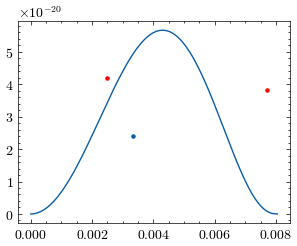

In [26]:
v_particles = np.zeros(n)

for i in tqdm(range(n)):
    v_particles[i] = sample_vel(radius_s[i], False)
    if i == n-1:     v_particles[i] = sample_vel(radius_s[i], True)
    

In [27]:
print(max(v_particles))

0.8730734014807341


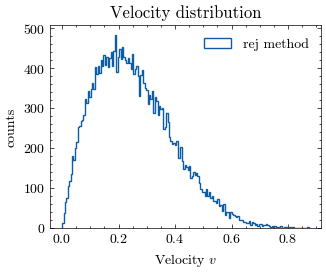

In [28]:
plt.figure()
plt.hist(v_particles, histtype = 'step', bins = int(np.sqrt(n)), label = 'rej method')
plt.xlabel("Velocity $v$")
plt.ylabel("counts")
plt.title("Velocity distribution")
plt.legend()
plt.show()

In [29]:
eps_particles = - (compute_potential(radius_s) + 0.5*v_particles**2)
print(min(eps_particles))

2.303981541424457e-05


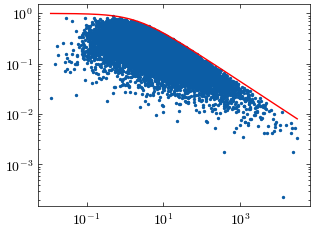

In [30]:
plt.plot(radius_s, np.sqrt(- 2 * compute_potential(radius_s)), c = 'r')
plt.scatter(radius_s, v_particles, s = 2)
plt.loglog()
plt.show()

In [31]:
P_theta_v = np.random.uniform(0, 1, n)
theta_v = np.arccos(1 - 2*P_theta_v)

P_phi_v = np.random.uniform(0, 1, n)
phi_v = 2 * np.pi * P_phi_v

vx, vy, vz = sph_to_carth (v_particles, theta_v, phi_v)

In [32]:
import datetime

def get_timestamp_filename():
    now = datetime.datetime.now()
    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
    return f"H_input_{timestamp}.txt"

In [33]:
filename = get_timestamp_filename()
print(filename)

H_input_2025-09-10_09-53-29.txt


In [34]:
# Metto insieme posizioni: (n+2, 3)
all_positions = np.zeros((n+2, 3))
all_positions[0] = x_1, y_1, z_1
all_positions[1] = x_2, y_2, z_2
all_positions[2:,0] = x
all_positions[2:,1] = y
all_positions[2:,2] = z

# Metto insieme velocità: (n+2, 3)
all_velocities = np.zeros((n+2, 3))
all_velocities[0] = v_x1, v_y1, v_z1
all_velocities[1] = v_x2, v_y2, v_z2
all_velocities[2:,0] = vx
all_velocities[2:,1] = vy
all_velocities[2:,2] = vz

# Metto insieme masse: (n+2,)
all_masses = np.zeros(n+2)
all_masses[0] = M_BH_1
all_masses[1] = M_BH_2
all_masses[2:] = M/n

# =========================================
# Calcolo e rimozione del CM iniziale
# =========================================
r_CM_init = np.sum(all_masses[:, None] * all_positions, axis=0) / np.sum(all_masses)
v_CM_init = np.sum(all_masses[:, None] * all_velocities, axis=0) / np.sum(all_masses)

print("CM iniziale pos:", r_CM_init)
print("CM iniziale vel:", v_CM_init)

# Shift di tutto
all_positions  -= r_CM_init
all_velocities -= v_CM_init

# =========================================
# Scrittura file input
# =========================================
with open(filename, 'w') as f:
    f.write(str(n + 2) + '\n')   # numero particelle
    f.write(str(n_dim) + '\n')   # dimensione
    f.write("0.0\n")             # tempo iniziale

    # masse
    for m in all_masses:
        f.write(str(m) + '\n')

    # posizioni
    for pos in all_positions:
        f.write(f"{pos[0]} {pos[1]} {pos[2]}\n")

    # velocità
    for vel in all_velocities:
        f.write(f"{vel[0]} {vel[1]} {vel[2]}\n")

CM iniziale pos: [ 0.33880137 -0.38424844 -2.60961148]
CM iniziale vel: [-0.00025497  0.00238106 -0.00071594]


In [35]:
sigma2 = M / (12 * a)
sigma = np.sqrt(sigma2)
print("Dispersione di velocità sigma =", sigma, "IU")

#raggio di influenza
def r_influence(M_BH):
    return M_BH / (sigma**2)

r_inf = r_influence (min(M_BH_1, M_BH_2))
softening = 0.5 * r_inf

print('suggested softening parameter = ', softening)

Dispersione di velocità sigma = 0.2041241452319315 IU
suggested softening parameter =  0.060000000000000005


In [36]:
day = str(datetime.datetime.now().day)
month = str(datetime.datetime.now().month)

In [37]:
folder = '../stellar_systems_dynamics2024/final_exercise/runs/' + day + '_' + month + '/'
outname=filename.replace('input', 'output')
logname=filename.replace('input', 'log')

In [38]:
np.sqrt(a**3 * 4) / 100

np.float64(0.0565685424949238)

In [39]:
alpha = 100
dtime = (1 / alpha) * (2 * np.pi * r_1 / v_circ(r_1))
tstop = 700
dtout = dtime

In [40]:
dtime

np.float64(1.4961371187718948)

In [41]:
command_line = ('./treecode in=' + folder + filename + ' out=' + folder + outname + 
                ' dtime=' + str(dtime) + ' eps=' + str(softening) + ' theta=0.5 tstop=' + str(tstop) + ' dtout=' + str(dtout) + ' > ' + folder + logname)

In [42]:
print(command_line)

./treecode in=../stellar_systems_dynamics2024/final_exercise/runs/10_9/H_input_2025-09-10_09-53-29.txt out=../stellar_systems_dynamics2024/final_exercise/runs/10_9/H_output_2025-09-10_09-53-29.txt dtime=1.4961371187718948 eps=0.060000000000000005 theta=0.5 tstop=700 dtout=1.4961371187718948 > ../stellar_systems_dynamics2024/final_exercise/runs/10_9/H_log_2025-09-10_09-53-29.txt


In [43]:
cmdname = filename.replace('input', 'cmd')

In [44]:
inputf = open(cmdname, 'w')

inputf.writelines(command_line)

inputf.close()

# Internal units to Physical units
We use the fact that $\frac{G M}{r v^2}$ is adimentional to infer the units of velocity and then those of time.
We will indicate with P our physical units (cgs) and with I the internal ones, where we fix $M_\odot$ as units of mass and kpc of lenght.

$$G_P = \frac{(\frac{r_P}{r_I})(\frac{v_P}{v_I})^2}{\frac{m_P}{m_I}} = 6.67 \times 10^{-8} \mathrm{cm}^3/\mathrm{g s}^2$$

which implies:

$$v_P = v_I \times \sqrt{G_P \, (\frac{m_P}{m_I}) \, (\frac{r_I}{r_P})} $$

In [45]:
from astropy import units as u
from astropy import constants as const

In [46]:
G_P = const.G.cgs

M_I = 1 * u.solMass
M_P = 10**10 * M_I.to(u.g)

R_I = 1 * u.kpc
R_P = 1 * R_I.to(u.cm)

v_conver = np.sqrt(G_P * (M_P/M_I) * (R_I/R_P))
print(v_conver)

20738652.969844207 cm kpc(1/2) / (solMass(1/2) s)


In [47]:
v_I = 1 * (u.solMass/u.kpc)**(1/2)
v_P = v_conver * v_I
print(v_I, ' = ', v_P)

1.0 solMass(1/2) / kpc(1/2)  =  20738652.969844207 cm / s


Given that $v_P$ is measured in cm/s, then $v_I$ is expressed in units of ($M_\odot$/kpc)$^{1/2}$:
$$ v_P = v_I \times 207.38652969844205 \frac{\mathrm{cm}}{\mathrm{s}}\frac{\mathrm{kpc}^{1/2}}{\mathrm{M_\odot}^{1/2}}$$

but since $v_I = \left[L/T\right]$ and lenght is measured in kpc:
$$ [T] = \frac{\mathrm{kpc}^{3/2}}{M_\odot^{1/2}} $$

If we take $\frac{G_PM_P}{v_P^3}$ this is in units of seconds and will be equal to $\frac{G_I M_I}{v_I^3}$:

$$\frac{G_I M_I}{v_I^3} = 1  \frac{\mathrm{kpc}^{3/2}}{M_\odot^{1/2}} = \frac{G_PM_P}{v_P^3} = ? \mathrm{s} $$

In [48]:
t_I = R_I / v_I
time_conv = (G_P * M_P / v_P**3) /t_I
print(time_conv)

148788717665424.5 s solMass(1/2) / kpc(3/2)


In [49]:
t_P = time_conv * t_I
print(t_I, ' = ', t_P, ' = ', t_P.to(u.Myr))

1.0 kpc(3/2) / solMass(1/2)  =  148788717665424.5 s  =  4.714829951118732 Myr


Virial radius = 200 * rho_c

In [50]:
crit_rho = 9E-30 *u.g/(u.cm)**3 #g / cm3
rho_200 = 200 * crit_rho * (M_I / M_P) / (R_I/R_P)**3
eps_rho = rho_200 / 10

rho_200

<Quantity 2.65961167e-06 solMass / kpc3>

for i in range(len(rho_grid)):
    if (rho_200 - eps_rho )*(u.kpc**3 / u.solMass) <= analytical_rho[i] <= (rho_200 + eps_rho )*(u.kpc**3 / u.solMass): print(rho_grid[i], compute_rho(rho_grid[i]))

### Dynamical Friction Timescale

The time it takes the perturber to reach the centre is dominated by the distribution potential, while dynamical friction is only a correction. We asssume that at each time the velocity of the perturber is the circular one (v_circ(radius)).

$$\frac{dv_M}{dt} = -16 \pi^2 m (M + m) \mathrm{ln}(\Lambda) \frac{\overline{v}_M}{|v_M|^3} \cdot \int_0^{v_M} f(v_m)v_m^2 dv_m $$

where $f(v_m)$ is our distribution function, which takes epsilon as input: at each radius, the potential is fixed and we need to integrate over all the possible velocities, which are between 0 and v_circ.

ln($\Lambda$)) is the Coulomb logarithm, originally defined as ln($\Lambda$)) = ln($\frac{b\mathrm{max}}{b\mathrm{min}}$) where $b_\mathrm{max}$ is in principle the radius of the distribution. We will choose b_max as the radius of the perturber and b_min as the softening of the system.

To get an estimate of the timescale from the acceleration, we use:

$$t_{df} \simeq \int_{r_{min }}^{r_{max}} \frac{v_{circ}}{|a_{df}| \cdot r} dr$$


In [146]:
def dyn_friction_accel (M, m, radius, softening): #Internal Units only
    norm = - 16 * np.pi**2 * (M + m) * m
    v_M = v_circ(radius)
    v_term = 1 / v_M**2

    Coulomb_l = np.log(radius_s[-1] / softening)
    
    v_space = np.linspace(0, v_M, 500)
    eps = - (compute_potential(radius) + 0.5*v_space**2)

    integral = np.trapezoid(df_norm(eps) * v_space**2, v_space)

    return norm * Coulomb_l * v_term * integral

def dyn_friction_timescale(M, m, radius_max, radius_min, softening):
    radii = np.linspace(radius_min, radius_max, 500)
    accel = np.array( [np.abs(dyn_friction_accel(M, m, r, softening)) for r in radii] )
    if 0 in accel: print('error, found acc = 0 at radius = ', radii[np.where(accel == 0)[0]])
    integrand = v_circ(radii) / (np.abs(accel) * radii)
    plt.plot(radii, integrand)
    plt.xlabel("Radius")
    plt.ylabel("Integrand (1/time)")
    plt.title("Dynamical Friction Integrand")
    return np.trapezoid(integrand, radii)

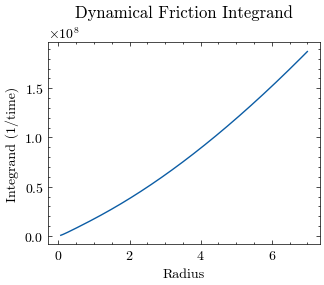

In [147]:
df_time = dyn_friction_timescale(M_BH_1, M/n, r_1, 1.1 * softening, 0.116)
df_time_IU = df_time * t_I
df_time_P = time_conv * df_time_IU

In [148]:
softening

np.float64(0.060000000000000005)

In [149]:
df_time_IU

<Quantity 5.69339554e+08 kpc(3/2) / solMass(1/2)>

In [150]:
df_time_P.to(u.Myr)

<Quantity 2.68433918e+09 Myr>